In [1]:
# CELL 1: IMPORTS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, joblib, time
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, roc_curve, precision_recall_curve
)
import xgboost as xgb

# Optional: LightGBM
try:
    import lightgbm as lgb
    LGBM_OK = True
    print(f' LightGBM {lgb.__version__} available')
except ImportError:
    LGBM_OK = False
    print('  LightGBM not found  →  pip install lightgbm')

os.makedirs('../results', exist_ok=True)
sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (14, 5), 'font.size': 11})

print('\n' + '='*60)
print('   NOTEBOOK 05: ENSEMBLE METHODS & STACKING')
print('='*60)

 LightGBM 4.6.0 available

   NOTEBOOK 05: ENSEMBLE METHODS & STACKING


In [2]:
# CELL 2: LOAD PREPROCESSED DATA + NB03 BASE MODELS

X_train = np.load('../data/X_train.npy')
y_train = np.load('../data/y_train.npy')
X_val   = np.load('../data/X_val.npy')
y_val   = np.load('../data/y_val.npy')
X_test  = np.load('../data/X_test.npy')
y_test  = np.load('../data/y_test.npy')
feature_names = pd.read_csv('../data/feature_names.csv')['feature'].tolist()

# Load the 3 base models saved in NB03
lr_model  = joblib.load('../results/model_lr.pkl')
rf_model  = joblib.load('../results/model_rf.pkl')
xgb_model = joblib.load('../results/model_xgb.pkl')  # or model_xgb_tuned.pkl

print(f'X_train : {X_train.shape}  Fraud: {y_train.mean()*100:.2f}% [SMOTE applied]')
print(f'X_val   : {X_val.shape}    Fraud: {y_val.mean()*100:.3f}%')
print(f'X_test  : {X_test.shape}   Fraud: {y_test.mean()*100:.3f}%')
print(f'\nBase models loaded:')
print(f'  LR  : {lr_model}')
print(f'  RF  : n_estimators={rf_model.n_estimators}')
print(f'  XGB : n_estimators={xgb_model.n_estimators}')

# Base model val-set probabilities (used throughout this notebook)
lr_val_probs  = lr_model.predict_proba(X_val)[:, 1]
rf_val_probs  = rf_model.predict_proba(X_val)[:, 1]
xgb_val_probs = xgb_model.predict_proba(X_val)[:, 1]

print('\nBase model val-set AUC-ROC:')
for name, probs in [('LR', lr_val_probs),('RF', rf_val_probs),('XGBoost', xgb_val_probs)]:
    print(f'  {name:8s}: {roc_auc_score(y_val, probs):.4f}')

X_train : (200157, 32)  Fraud: 9.09% [SMOTE applied]
X_val   : (45569, 32)    Fraud: 0.173%
X_test  : (56962, 32)   Fraud: 0.172%

Base models loaded:
  LR  : LogisticRegression(C=0.01, class_weight='balanced', max_iter=1000, n_jobs=-1,
                   random_state=42)
  RF  : n_estimators=200
  XGB : n_estimators=500

Base model val-set AUC-ROC:
  LR      : 0.9704
  RF      : 0.9630
  XGBoost : 0.9659


In [3]:
# CELL 3: SOFT VOTING ENSEMBLE
# Why? Averaging probabilities reduces variance.
# Individual model errors partially cancel each other out.
# Even if XGBoost is best, voting occasionally fixes its errors
# using RF or LR predictions.

print('=== Soft Voting Ensembles ===')
print('How it works: average P(fraud) across all base models')
print('  Equal weights  : (LR + RF + XGB) / 3')
print('  Optimal weights: found by grid search on val set')

def eval_probs(probs, y_true, threshold=0.3):
    auc  = roc_auc_score(y_true, probs)
    ap   = average_precision_score(y_true, probs)
    pred = (probs >= threshold).astype(int)
    f1   = f1_score(y_true, pred)
    rec  = recall_score(y_true, pred)
    pre  = precision_score(y_true, pred)
    return {'auc': auc, 'ap': ap, 'f1': f1, 'recall': rec, 'precision': pre}

# Equal voting
vote_equal = (lr_val_probs + rf_val_probs + xgb_val_probs) / 3

# Grid search for best weights (w_lr, w_rf, w_xgb) on validation set
best_auc, best_w = 0, (0.1, 0.2, 0.7)
for w1 in np.arange(0.0, 0.4, 0.05):
    for w2 in np.arange(0.1, 0.5, 0.05):
        w3 = round(1 - w1 - w2, 4)
        if 0 < w3 <= 1:
            blended = w1*lr_val_probs + w2*rf_val_probs + w3*xgb_val_probs
            auc = roc_auc_score(y_val, blended)
            if auc > best_auc:
                best_auc, best_w = auc, (w1, w2, w3)

w_lr, w_rf, w_xgb = best_w
vote_optimal = w_lr*lr_val_probs + w_rf*rf_val_probs + w_xgb*xgb_val_probs

# Report
results_all = {}
for name, probs in [
    ('XGBoost (NB03 base)',  xgb_val_probs),
    ('Equal Voting (1/3 each)', vote_equal),
    (f'Optimal Voting ({w_lr:.2f}/{w_rf:.2f}/{w_xgb:.2f})', vote_optimal),
]:
    m = eval_probs(probs, y_val)
    results_all[name] = {**m, 'probs': probs}
    print(f'\n  {name}')
    print(f'    AUC-ROC={m["auc"]:.4f}  AP={m["ap"]:.4f}  F1={m["f1"]:.4f}  Recall={m["recall"]:.4f}  Precision={m["precision"]:.4f}')

print(f'\n  Optimal weights: LR={w_lr:.2f}, RF={w_rf:.2f}, XGB={w_xgb:.2f}')

=== Soft Voting Ensembles ===
How it works: average P(fraud) across all base models
  Equal weights  : (LR + RF + XGB) / 3
  Optimal weights: found by grid search on val set

  XGBoost (NB03 base)
    AUC-ROC=0.9659  AP=0.7769  F1=0.2642  Recall=0.8228  Precision=0.1574

  Equal Voting (1/3 each)
    AUC-ROC=0.9716  AP=0.7843  F1=0.1702  Recall=0.8734  Precision=0.0943

  Optimal Voting (0.15/0.45/0.40)
    AUC-ROC=0.9719  AP=0.7810  F1=0.3508  Recall=0.8481  Precision=0.2211

  Optimal weights: LR=0.15, RF=0.45, XGB=0.40


In [4]:
# CELL 4: LIGHTGBM
# How LightGBM differs from XGBoost:
#   XGBoost  → level-wise tree growth (splits all leaves at same depth)
#   LightGBM → leaf-wise tree growth (splits the leaf with highest gain)
#   LightGBM is typically 3-5x faster with similar or better accuracy

if LGBM_OK:
    print('=== LightGBM Training ===')
    print('Algorithm: Gradient boosted trees with LEAF-wise growth')
    print('  Advantage: faster training, often higher accuracy on large datasets')

    spw = (y_train == 0).sum() / (y_train == 1).sum()

    lgbm_model = lgb.LGBMClassifier(
        n_estimators     = 600,
        num_leaves       = 63,          # richer than XGB max_depth=6
        max_depth        = -1,          # no depth limit (leaf-wise controls this)
        learning_rate    = 0.05,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        scale_pos_weight = spw,
        reg_alpha        = 0.1,
        reg_lambda       = 1.0,
        min_child_samples= 20,
        random_state     = 42,
        n_jobs           = -1,
        verbose          = -1,
    )

    t0 = time.time()
    lgbm_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=30, verbose=False),
            lgb.log_evaluation(period=9999)   # silent
        ]
    )
    lgbm_time = time.time() - t0

    lgbm_val_probs = lgbm_model.predict_proba(X_val)[:, 1]
    m_lgb = eval_probs(lgbm_val_probs, y_val)
    results_all['LightGBM'] = {**m_lgb, 'probs': lgbm_val_probs}

    print(f'\nLightGBM Results (val set):')
    print(f'  Training time  : {lgbm_time:.1f}s')
    print(f'  Best iteration : {lgbm_model.best_iteration_}')
    print(f'  AUC-ROC  : {m_lgb["auc"]:.4f}')
    print(f'  Avg Prec : {m_lgb["ap"]:.4f}')
    print(f'  F1-Score : {m_lgb["f1"]:.4f}')
    print(f'  Recall   : {m_lgb["recall"]:.4f}')

    joblib.dump(lgbm_model, '../results/model_lgbm.pkl')
    print('  Saved → results/model_lgbm.pkl')
else:
    print('   LightGBM skipped (not installed)')
    lgbm_val_probs = None

=== LightGBM Training ===
Algorithm: Gradient boosted trees with LEAF-wise growth
  Advantage: faster training, often higher accuracy on large datasets

LightGBM Results (val set):
  Training time  : 6.4s
  Best iteration : 241
  AUC-ROC  : 0.9756
  Avg Prec : 0.8237
  F1-Score : 0.7975
  Recall   : 0.8228
  Saved → results/model_lgbm.pkl


In [5]:
#  CELL 5: STACKING CLASSIFIER
#
# Architecture:
#   Level 1 │ LR ──────────┐
#   Base     │ RF ──────────┼──► Level 2 Meta-LR ──► Final score
#   Models   │ XGBoost ─────┘
#
# Training: 5-fold CV on train set
#   Each base model predicts on the fold it was NOT trained on
#   Meta-learner trains on those out-of-fold predictions
#   → Meta-learner learns WHEN to trust each base model


print('=== Stacking Classifier (Level-2 Meta-Learner) ===')
print('Level 1 : LR + RF + XGBoost (trained with 5-fold CV)')
print('Level 2 : Logistic Regression on base model outputs')
print(' This takes ~3-5 min (5-fold CV × 3 models)...')

spw = (y_train == 0).sum() / (y_train == 1).sum()

base_estimators = [
    ('lr', LogisticRegression(
        C=0.01, max_iter=1000, class_weight='balanced',
        solver='lbfgs', random_state=42
    )),
    ('rf', RandomForestClassifier(
        n_estimators=100, max_depth=12, class_weight='balanced',
        random_state=42, n_jobs=-1
    )),
    ('xgb', xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        scale_pos_weight=spw, subsample=0.8, colsample_bytree=0.8,
        eval_metric='aucpr', random_state=42, n_jobs=-1, verbosity=0
    ))
]

stacking_clf = StackingClassifier(
    estimators      = base_estimators,
    final_estimator = LogisticRegression(C=1.0, max_iter=500, random_state=42),
    cv              = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    stack_method    = 'predict_proba',
    passthrough     = False,
    n_jobs          = -1
)

t0 = time.time()
stacking_clf.fit(X_train, y_train)
stack_time = time.time() - t0

stack_val_probs = stacking_clf.predict_proba(X_val)[:, 1]
m_stack = eval_probs(stack_val_probs, y_val)
results_all['Stacking (LR+RF+XGB → LR)'] = {**m_stack, 'probs': stack_val_probs}

print(f'\n Stacking Results (val set):')
print(f'  Training time : {stack_time:.1f}s')
print(f'  AUC-ROC  : {m_stack["auc"]:.4f}')
print(f'  Avg Prec : {m_stack["ap"]:.4f}')
print(f'  F1-Score : {m_stack["f1"]:.4f}')
print(f'  Recall   : {m_stack["recall"]:.4f}')

joblib.dump(stacking_clf, '../results/model_stacking.pkl')
print(' Saved → results/model_stacking.pkl')

=== Stacking Classifier (Level-2 Meta-Learner) ===
Level 1 : LR + RF + XGBoost (trained with 5-fold CV)
Level 2 : Logistic Regression on base model outputs
 This takes ~3-5 min (5-fold CV × 3 models)...

 Stacking Results (val set):
  Training time : 308.1s
  AUC-ROC  : 0.9663
  Avg Prec : 0.7625
  F1-Score : 0.7381
  Recall   : 0.7848
 Saved → results/model_stacking.pkl


In [6]:
# CELL 6: PROBABILITY CALIBRATION
# Why calibrate?
# Raw XGBoost probabilities ≠ actual fraud probabilities
# Example: model outputs 0.8 but only 50% of those are fraud
# Calibration fixes this → important for threshold selection
# and business risk calculations
#
# Methods:
#   Platt Scaling : fits sigmoid on val set (parametric)
#   Isotonic Reg  : fits step function (non-parametric, more flexible)

print('=== Probability Calibration ===')
print('Problem: raw model scores ≠ real probability of fraud')
print('Goal   : model outputs 0.80 → 80% of those txs are actually fraud')

# Calibrate XGBoost using val set (cv='prefit' = already trained)
calibrated_platt = CalibratedClassifierCV(xgb_model, method='sigmoid',  cv='prefit')
calibrated_iso   = CalibratedClassifierCV(xgb_model, method='isotonic', cv='prefit')

calibrated_platt.fit(X_val, y_val)
calibrated_iso.fit(X_val, y_val)

# Evaluate on TEST set
raw_test_probs   = xgb_model.predict_proba(X_test)[:, 1]
platt_test_probs = calibrated_platt.predict_proba(X_test)[:, 1]
iso_test_probs   = calibrated_iso.predict_proba(X_test)[:, 1]

print('\nTest set performance (AUC-ROC | Avg Precision):')
for name, probs in [
    ('Raw XGBoost',        raw_test_probs),
    ('Platt Scaled',       platt_test_probs),
    ('Isotonic Regression',iso_test_probs)
]:
    auc = roc_auc_score(y_test, probs)
    ap  = average_precision_score(y_test, probs)
    print(f'  {name:25s}: AUC={auc:.4f} | AP={ap:.4f}')

joblib.dump(calibrated_platt, '../results/model_xgb_calibrated.pkl')
print('\n  Saved → results/model_xgb_calibrated.pkl')

=== Probability Calibration ===
Problem: raw model scores ≠ real probability of fraud
Goal   : model outputs 0.80 → 80% of those txs are actually fraud

Test set performance (AUC-ROC | Avg Precision):
  Raw XGBoost              : AUC=0.9782 | AP=0.8328
  Platt Scaled             : AUC=0.9782 | AP=0.8328
  Isotonic Regression      : AUC=0.9755 | AP=0.7879

  Saved → results/model_xgb_calibrated.pkl


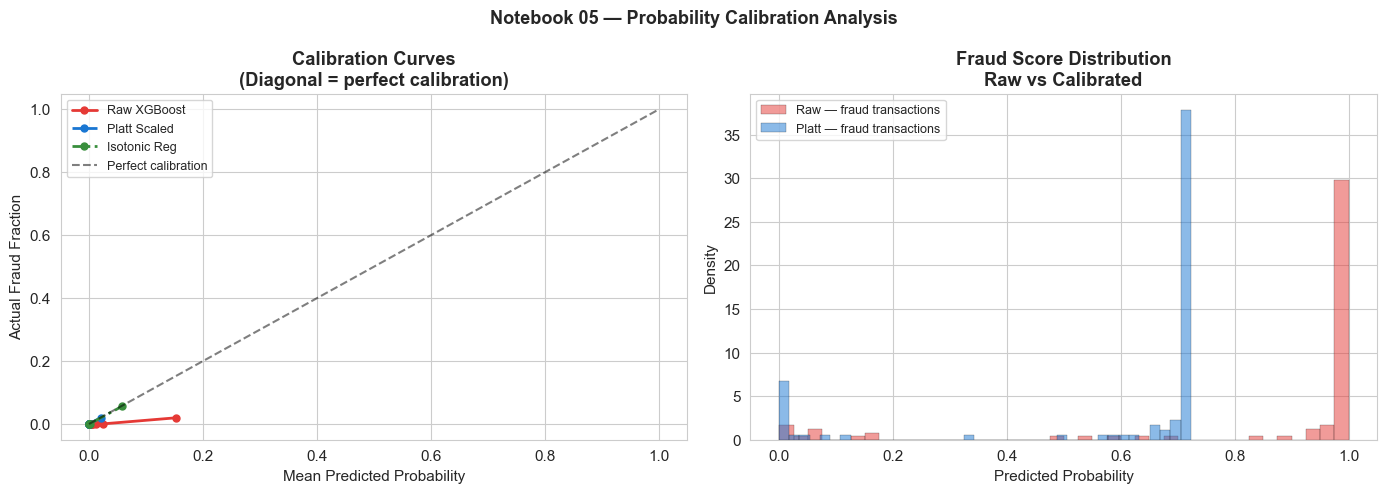

 Saved → results/nb05_calibration.png


In [7]:
#  CELL 7: CALIBRATION CURVE PLOTS
# A perfect calibration: predicted_prob = actual_fraud_rate
# → points fall on the diagonal (y=x line)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Calibration curves ---
for name, probs, color, ls in [
    ('Raw XGBoost',    raw_test_probs,   '#E53935', '-'),
    ('Platt Scaled',   platt_test_probs, '#1976D2', '--'),
    ('Isotonic Reg',   iso_test_probs,   '#388E3C', '-.')
]:
    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=12, strategy='quantile')
    axes[0].plot(mean_pred, frac_pos, marker='o', color=color,
                 linestyle=ls, linewidth=2, markersize=5, label=name)

axes[0].plot([0,1],[0,1], 'k--', alpha=0.5, linewidth=1.5, label='Perfect calibration')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Actual Fraud Fraction')
axes[0].set_title('Calibration Curves\n(Diagonal = perfect calibration)', fontweight='bold')
axes[0].legend(fontsize=9)

# --- Right: Probability density before/after ---
fraud_mask = y_test == 1
axes[1].hist(raw_test_probs[fraud_mask],   bins=40, alpha=0.5, color='#E53935',
             label='Raw — fraud transactions',   density=True, edgecolor='black', lw=0.3)
axes[1].hist(platt_test_probs[fraud_mask], bins=40, alpha=0.5, color='#1976D2',
             label='Platt — fraud transactions', density=True, edgecolor='black', lw=0.3)
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Density')
axes[1].set_title('Fraud Score Distribution\nRaw vs Calibrated', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Notebook 05 — Probability Calibration Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/nb05_calibration.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved → results/nb05_calibration.png')



In [8]:
pip install lightgbm


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [9]:
# CELL 8: COMPLETE COMPARISON — ALL METHODS ON TEST SET

print('=== Final Leaderboard — Test Set (unseen data) ===')
print('Threshold = 0.30 (business cost-optimised from NB03)')

# Collect test set probs for all methods
lr_test_probs   = lr_model.predict_proba(X_test)[:, 1]
rf_test_probs   = rf_model.predict_proba(X_test)[:, 1]
xgb_test_probs  = xgb_model.predict_proba(X_test)[:, 1]
vote_eq_test    = (lr_test_probs + rf_test_probs + xgb_test_probs) / 3
vote_opt_test   = w_lr*lr_test_probs + w_rf*rf_test_probs + w_xgb*xgb_test_probs
stack_test_probs = stacking_clf.predict_proba(X_test)[:, 1]
platt_test      = calibrated_platt.predict_proba(X_test)[:, 1]

test_models = {
    'LR (NB03)':            lr_test_probs,
    'RF (NB03)':            rf_test_probs,
    'XGBoost (NB03)':       xgb_test_probs,
    'Equal Voting':         vote_eq_test,
    'Optimal Voting':       vote_opt_test,
    'Stacking Ensemble':    stack_test_probs,
    'XGBoost + Calibration': platt_test,
}
if LGBM_OK:
    test_models['LightGBM'] = lgbm_model.predict_proba(X_test)[:, 1]

rows = []
for name, probs in test_models.items():
    m = eval_probs(probs, y_test, threshold=0.30)
    rows.append({'Model': name, 'AUC-ROC': m['auc'], 'Avg Prec': m['ap'],
                 'Recall': m['recall'], 'Precision': m['precision'], 'F1': m['f1']})

lb = pd.DataFrame(rows).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
lb.index += 1  # 1-based ranking
print(lb.round(4).to_string())
print(f'\n  Best model: {lb.iloc[0]["Model"]}  (AUC-ROC = {lb.iloc[0]["AUC-ROC"]:.4f})')

# Save best model name
best_name  = lb.iloc[0]['Model']
best_probs = test_models[best_name]
lb.to_csv('../results/ensemble_leaderboard.csv', index=True)
print('  Saved → results/ensemble_leaderboard.csv')

=== Final Leaderboard — Test Set (unseen data) ===
Threshold = 0.30 (business cost-optimised from NB03)
                   Model  AUC-ROC  Avg Prec  Recall  Precision      F1
1      Stacking Ensemble   0.9901    0.8292  0.8673     0.6489  0.7424
2               LightGBM   0.9864    0.8757  0.8776     0.7350  0.8000
3         Optimal Voting   0.9788    0.8479  0.8878     0.2033  0.3308
4              RF (NB03)   0.9784    0.8510  0.8878     0.5370  0.6692
5         XGBoost (NB03)   0.9782    0.8328  0.8878     0.1460  0.2507
6  XGBoost + Calibration   0.9782    0.8328  0.8367     0.6833  0.7523
7           Equal Voting   0.9773    0.8488  0.8980     0.0930  0.1686
8              LR (NB03)   0.9728    0.7179  0.9184     0.0291  0.0563

  Best model: Stacking Ensemble  (AUC-ROC = 0.9901)
  Saved → results/ensemble_leaderboard.csv


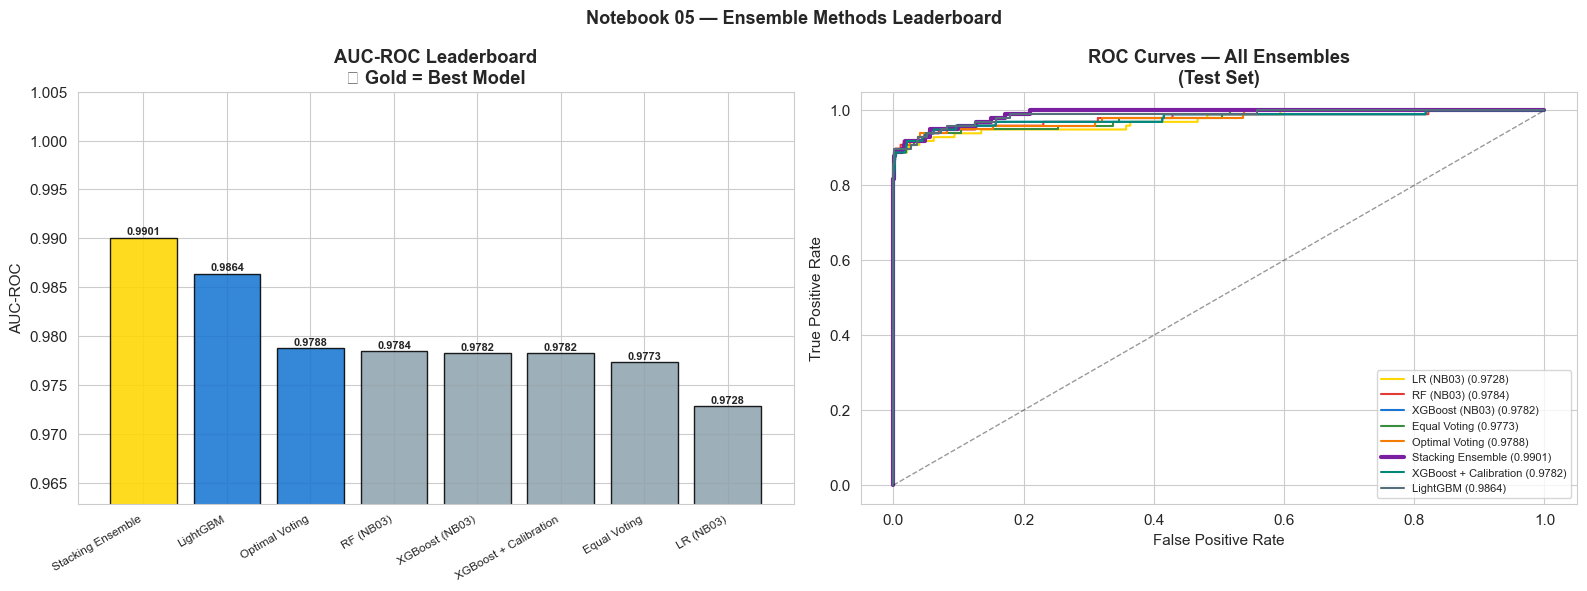

 Saved → results/nb05_ensemble_leaderboard.png

    NOTEBOOK 05 COMPLETE
  Methods compared  : 8
  Best method       : Stacking Ensemble
  Best AUC-ROC      : 0.9901
  Best Recall       : 0.8673

  Saved models:
    results/model_lgbm.pkl          (LightGBM)
    results/model_stacking.pkl      (Stacking)
    results/model_xgb_calibrated.pkl(XGB+Calibration)

     Use best model in NB07 (Deployment API)


In [11]:
# CELL 9: LEADERBOARD VISUALISATION

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

palette = ['#FFD700' if i == 0 else '#1976D2' if i < 3 else '#90A4AE'
           for i in range(len(lb))]

# AUC-ROC bar chart
axes[0].bar(range(len(lb)), lb['AUC-ROC'], color=palette, edgecolor='black', alpha=0.88)
axes[0].set_xticks(range(len(lb)))
axes[0].set_xticklabels(lb['Model'], rotation=30, ha='right', fontsize=8.5)
axes[0].set_ylim(lb['AUC-ROC'].min() - 0.01, 1.005)
axes[0].set_ylabel('AUC-ROC')
axes[0].set_title('AUC-ROC Leaderboard\n🥇 Gold = Best Model', fontweight='bold')
for i, v in enumerate(lb['AUC-ROC']):
    axes[0].text(i, v + 0.0003, f'{v:.4f}', ha='center', fontsize=8, fontweight='bold')

# ROC curves overlay
curve_colors = ['#FFD700','#E53935','#1976D2','#388E3C','#F57C00','#7B1FA2','#00897B','#546E7A']
for (name, probs), color in zip(test_models.items(), curve_colors):
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    lw  = 3 if name == best_name else 1.5
    axes[1].plot(fpr, tpr, color=color, linewidth=lw, label=f'{name} ({auc:.4f})')

axes[1].plot([0,1],[0,1],'k--', alpha=0.4, linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves — All Ensembles\n(Test Set)', fontweight='bold')
axes[1].legend(fontsize=8, loc='lower right')

plt.suptitle('Notebook 05 — Ensemble Methods Leaderboard', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/nb05_ensemble_leaderboard.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved → results/nb05_ensemble_leaderboard.png')

print('\n' + '='*60)
print('    NOTEBOOK 05 COMPLETE')
print('='*60)
print(f'  Methods compared  : {len(test_models)}')
print(f'  Best method       : {best_name}')
print(f'  Best AUC-ROC      : {lb.iloc[0]["AUC-ROC"]:.4f}')
print(f'  Best Recall       : {lb.iloc[0]["Recall"]:.4f}')
print('\n  Saved models:')
print('    results/model_lgbm.pkl          (LightGBM)')
print('    results/model_stacking.pkl      (Stacking)')
print('    results/model_xgb_calibrated.pkl(XGB+Calibration)')
print('\n     Use best model in NB07 (Deployment API)')